# Single tx dataset

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def load_data(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    # Basic sanity checks
    expected_cols = {"metapath", "difference"}
    if not expected_cols.issubset(df.columns):
        raise ValueError(
            f"CSV must contain columns {expected_cols}, found {set(df.columns)}"
        )

    # Ensure 'difference' is numeric
    df["difference"] = pd.to_numeric(df["difference"], errors="coerce")
    if df["difference"].isna().any():
        n_bad = df["difference"].isna().sum()
        print(f"Warning: {n_bad} row(s) had non-numeric 'difference' values and were dropped.")
        df = df.dropna(subset=["difference"])

    return df

df = load_data("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/single-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/dme_report.csv")
df["abs_difference"] = df["difference"].abs()

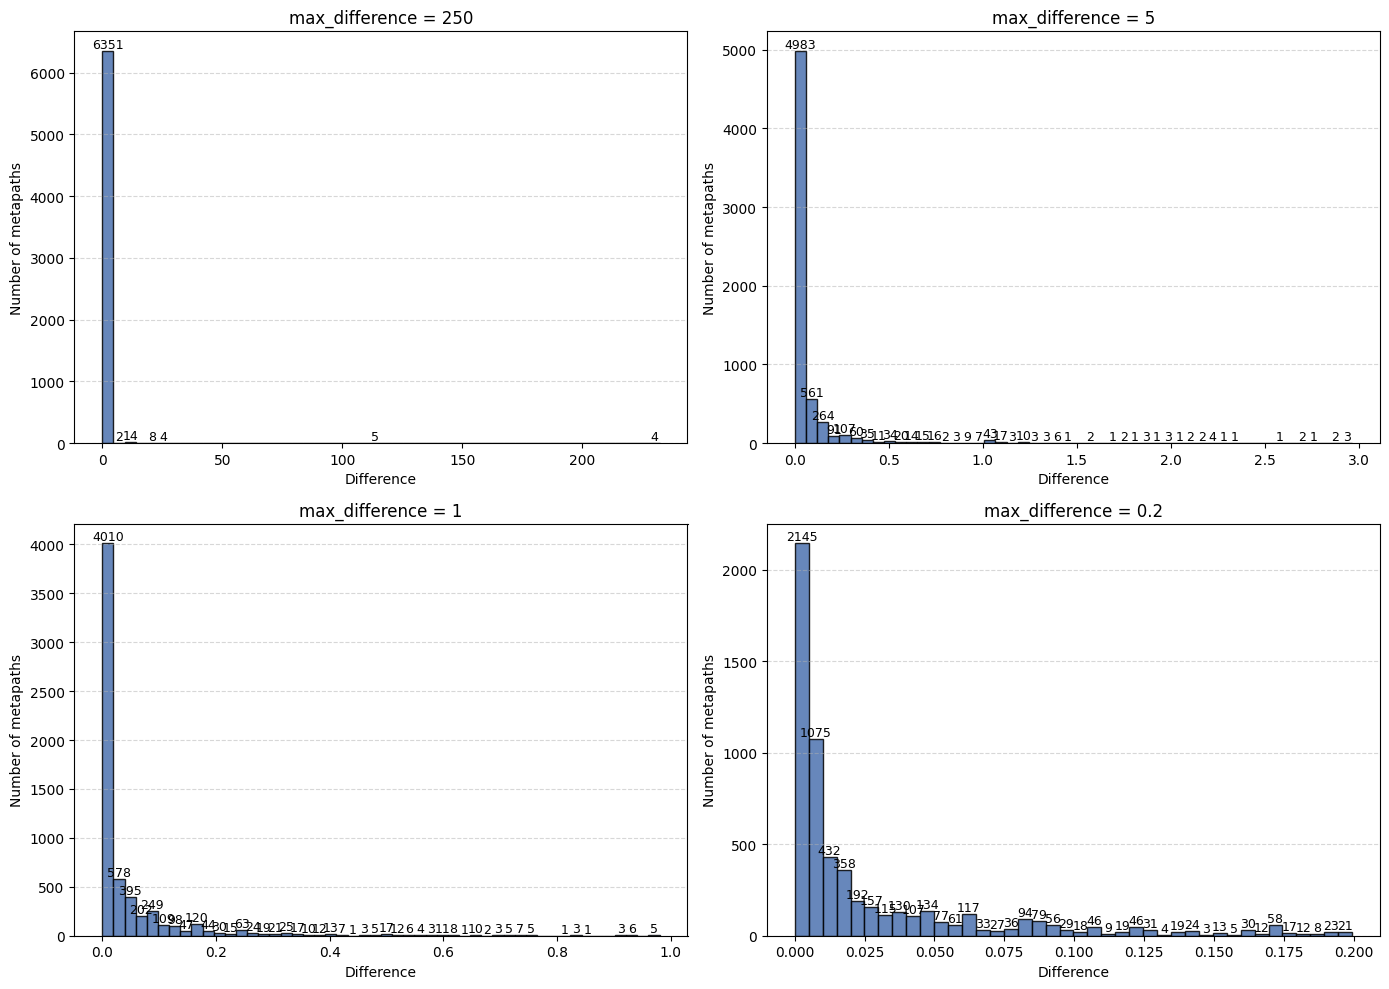

In [13]:
def plot_histogram(df: pd.DataFrame, bins: int, max_difference: float, interval_size: float = None, ax=None, ax_index: int = 0):
    """
    Plot histogram of abs_difference up to max_difference.
    If `interval_size` is provided, bins are calculated as max_difference / interval_size.
    Otherwise, uses the provided bins argument.
    If `ax` is None a new figure/axis is created.
    If `ax` is an array-like of axes (or a numpy.ndarray) the axis at ax_index is used.
    """
    # choose axis
    if ax is None:
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(1, 1, 1)
    else:
        # handle numpy.ndarray, list, tuple, or similar containers of Axes
        try:
            # numpy.ndarray has flatten(); use it if available
            if hasattr(ax, "flatten"):
                ax = ax.flatten()[ax_index]
            else:
                ax = ax[ax_index]
        except Exception:
            # if ax is already a single Axes object, leave it
            pass

    # Calculate bins based on interval_size if provided
    if interval_size is not None:
        bins = max(1, int(max_difference / interval_size))

    filtered_df = df[df["abs_difference"] <= max_difference]
    ax.hist(
        filtered_df["abs_difference"],
        bins=bins,
        color="#4C72B0",
        edgecolor="black",
        alpha=0.85,
    )

    ax.set_xlabel("Difference")
    ax.set_ylabel("Number of metapaths")
    ax.set_title(f"max_difference = {max_difference}")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    # Annotate bar counts above each bin
    counts, bin_edges = np.histogram(
        filtered_df["abs_difference"],
        bins=bins,
    )
    for count, left_edge, right_edge in zip(counts, bin_edges[:-1], bin_edges[1:]):
        if count > 0:
            ax.text(
                (left_edge + right_edge) / 2,
                count,
                int(count),
                ha="center",
                va="bottom",
                fontsize=9,
            )

    plt.tight_layout()
    return ax

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
plot_histogram(df, 50, 250, ax=ax, ax_index=0, interval_size=5)
plot_histogram(df, 50, 5, ax=ax, ax_index=1, interval_size=0.1)
plot_histogram(df, 50, 1, ax=ax, ax_index=2, interval_size=0.02)
plot_histogram(df, 50, 0.2, ax=ax, ax_index=3, interval_size=0.005)
plt.tight_layout()

<module 'matplotlib.pyplot' from '/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/.venv/lib/python3.14/site-packages/matplotlib/pyplot.py'>

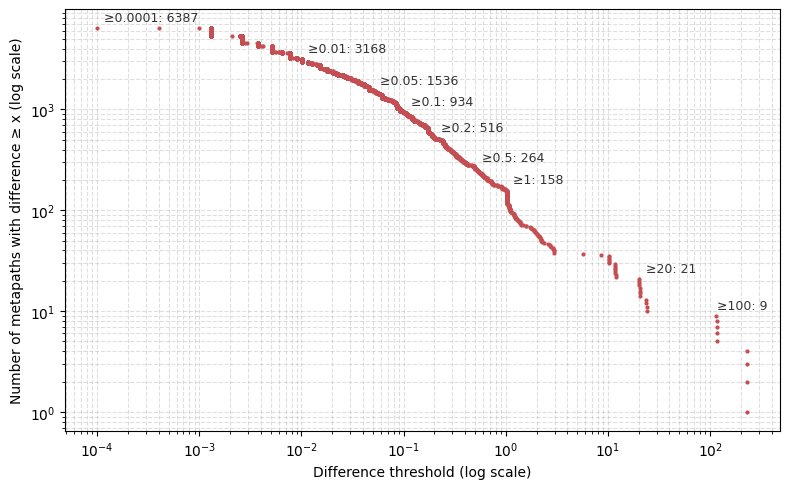

In [14]:
def compute_ccdf(values: np.ndarray):
    """Return (sorted_values, ccdf) where ccdf[i] = count of values >= sorted_values[i]."""
    sorted_vals = np.sort(values)[::-1]  # descending
    n = len(sorted_vals)
    ccdf_counts = np.arange(1, n + 1)  # rank of each value when sorted descending
    return sorted_vals, ccdf_counts
 
 
def plot_ccdf(dfs: dict[str, pd.DataFrame], thresholds: list, colors: dict[str, str] = None):
    default_colors = ["#C44E52", "#4C72B0", "#55A868", "#8172B3", "#CCB974", "#64B5CD"]
    if colors is None:
        colors = {label: default_colors[i % len(default_colors)] for i, label in enumerate(dfs)}

    fig, ax = plt.subplots(figsize=(8, 5))

    for i, (label, df) in enumerate(dfs.items()):
        values = df["abs_difference"].to_numpy()
        sorted_vals, ccdf_counts = compute_ccdf(values)
        ax.plot(sorted_vals, ccdf_counts, marker=".", linestyle="none", markersize=4, color=colors[label], label=label)
 
        for t in thresholds:
            count_ge_t = int((sorted_vals >= t).sum())
            if count_ge_t > 0:
                ax.annotate(
                    f"\u2265{t}: {count_ge_t}",
                    xy=(t, count_ge_t),
                    xytext=(5, 5) if len(dfs) == 1 or i % 2 == 1 else (-5, -10),
                    horizontalalignment="left" if len(dfs) == 1 or i % 2 == 1 else "right",
                    textcoords="offset points",
                    fontsize=9,
                    color="#333333" if len(dfs) == 1 else colors[label],
                )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Difference threshold (log scale)")
    ax.set_ylabel("Number of metapaths with difference \u2265 x (log scale)")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    if len(dfs) > 1:
        ax.legend(loc="upper right")

    plt.tight_layout()
 
    # print(f"\nTotal metapaths: {n_total}")
    # print("Reference thresholds:")
    # for t in thresholds:
    #     count_ge_t = int((sorted_vals >= t).sum())
    #     print(f"  difference >= {t:>6}: {count_ge_t}")
    
    return plt

thresholds = [0.0001, 0.01, 0.05, 0.1, 0.2, 0.5, 1, 20, 100]
plt = plot_ccdf({"Single-chain": df}, thresholds)
plt

In [15]:
def min_threshold_for_percentage(df: pd.DataFrame, percentage: float, column: str = "difference") -> float:
    """
    Find the minimum 'difference' threshold t such that at least
    `percentage`% of the metapaths in df have difference >= t.
 
    In other words: what's the lowest bar I can set such that
    `percentage`% of the data still clears it?
 
    Parameters
    ----------
    df : pd.DataFrame
        Must contain the given `column` (default 'difference').
    percentage : float
        Target percentage of metapaths to retain, in (0, 100].
        e.g. 90 -> threshold below which 90% of metapaths remain (difference >= t).
    column : str
        Name of the numeric column to threshold on.
 
    Returns
    -------
    float
        The threshold value t.
    """
    if not (0 < percentage <= 100):
        raise ValueError("percentage must be in the range (0, 100]")
 
    values = df[column].dropna().to_numpy()
    if len(values) == 0:
        raise ValueError(f"No valid values found in column '{column}'")
 
    # We want: count(values >= t) / n >= percentage / 100
    # Equivalently: t is the (100 - percentage)-th percentile of the data,
    # using the "lower" interpolation so the guarantee (>= t) is not violated
    # by interpolated values that don't actually exist in the dataset.
    quantile_point = (100 - percentage) / 100
    threshold = np.quantile(values, quantile_point, method="lower")
 
    return float(threshold)
 
 
def thresholds_for_percentages(df: pd.DataFrame, percentages, column: str = "abs_difference") -> pd.DataFrame:
    """
    Convenience wrapper: compute thresholds for a list of percentages at once.
 
    Returns a DataFrame with columns: percentage, threshold, n_metapaths_retained
    """
    values = df[column].dropna().to_numpy()
    n_total = len(values)
 
    rows = []
    for p in percentages:
        t = min_threshold_for_percentage(df, p, column)
        n_retained = int((values >= t).sum())
        rows.append({
            "percentage": p,
            "threshold": t,
            "n_metapaths_retained": n_retained,
            "pct_actually_retained": round(100 * n_retained / n_total, 2),
        })
 
    return pd.DataFrame(rows)

thresholds_df = thresholds_for_percentages(df, [100, 50, 30, 20, 10, 5, 4, 2, 1, 0.5])
thresholds_df

,percentage,threshold,n_metapaths_retained,pct_actually_retained
0,100.0,0.0000,6388,100.00
1,50.0,0.0090,3238,50.69
2,30.0,0.0345,1931,30.23
3,20.0,0.0665,1284,20.10
4,10.0,0.1726,652,10.21
5,5.0,0.3642,322,5.04
6,4.0,0.5064,257,4.02
7,2.0,1.0254,136,2.13
8,1.0,1.7877,65,1.02
9,0.5,10.1624,33,0.52


## Evaluation Runs

In [16]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from types import SimpleNamespace

from cli import Cli
from dataset_generator.types import DATASET_TYPE

# Define the absolute path for the root directory for outputs here (and if possible, make sure to have a prepared _dataset folder)
OUTPUTS_ROOT = Path("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/single-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge")

The next cells will run the model training for different metapath difference thresholds.

This process can take a long time to finish.

**If you already have the models trained, you can skip this section and go to the evaluation section.**

In [17]:
dataset_path = OUTPUTS_ROOT.absolute() / "_dataset"
fixed_args = {
    "device": "cpu",  # Change to "cuda" if you have a GPU and want to use it
    "dataset": DATASET_TYPE.SINGLE,
    "load_data": str(dataset_path),
    "new_dataset": None,
    "force_reload": False,
    "num_workers": 0,
    "tags": "mlpbased,tuningdme",

    "num_epochs": 100,
    "learning_rate": 0.005,
    "augment_factor": 0,
    "rm_semantic_fusion": True,
    "early_stopping": 15,
    "kfolds": 5,
    "first_layer_channels": 128,
    "hidden_channels": 64,
    "dropout": 0.5,
    "input_drop": 0.0,
    "att_drop": 0.0,
    "n_fp_layers": 2,
    "n_mlp_layers": 2,
    "activation": "relu",
    "pooling": "mean",
    "residual": False,
    "random_seed": 42,
    "test_split": 0.15,
}

In [18]:
# Run for 0.5%
dme_val = min_threshold_for_percentage(df, 0.5, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

Early stopping: 15
Exporting data from database to CSV files... 
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 782 normal, 197 anomaly.
Identified 33 differential meta-paths for training.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 0.6205, val loss: 0.5698, PR-AUC (anomaly): 0.4894, f2-score (anomaly): 0.3571
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       157
           1       1.00      0.31      0.47        39

    accuracy                           0.86       196
   macro avg       0.93      0.65      0.70       196
weighted avg       0.88      0.86      0.83       196

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch 2, train loss: 0.5629, val loss: 0.5554, PR-AUC (anomaly): 0.5057, f2-score (anomaly): 0.3571
              precision    recall  f1-score   supp

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/single-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme10.1624_nosf_es15_mlpbased_tuningdme__202608101709'

In [19]:
# Run for 1%
dme_val = min_threshold_for_percentage(df, 1, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

Early stopping: 15
Exporting data from database to CSV files... 
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 782 normal, 197 anomaly.
Identified 65 differential meta-paths for training.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 0.5507, val loss: 0.3265, PR-AUC (anomaly): 0.9020, f2-score (anomaly): 0.7613
              precision    recall  f1-score   support

           0       0.98      0.68      0.80       157
           1       0.43      0.95      0.59        39

    accuracy                           0.73       196
   macro avg       0.70      0.82      0.70       196
weighted avg       0.87      0.73      0.76       196

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch 2, train loss: 0.3563, val loss: 0.1477, PR-AUC (anomaly): 0.9549, f2-score (anomaly): 0.9653
              precision    recall  f1-score   supp

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/single-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme1.7877_nosf_es15_mlpbased_tuningdme__202608101711'

In [20]:
# Run for 2%
dme_val = min_threshold_for_percentage(df, 2, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

Early stopping: 15
Exporting data from database to CSV files... 
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 782 normal, 197 anomaly.
Identified 119 differential meta-paths for training.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 0.5338, val loss: 0.1895, PR-AUC (anomaly): 0.9302, f2-score (anomaly): 0.9286
              precision    recall  f1-score   support

           0       1.00      0.90      0.95       157
           1       0.72      1.00      0.84        39

    accuracy                           0.92       196
   macro avg       0.86      0.95      0.89       196
weighted avg       0.94      0.92      0.93       196

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch 2, train loss: 0.1951, val loss: 0.1054, PR-AUC (anomaly): 0.9279, f2-score (anomaly): 0.9606
              precision    recall  f1-score   sup

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/single-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme1.0254_nosf_es15_mlpbased_tuningdme__202608101713'

In [21]:
# Run for 5%
dme_val = min_threshold_for_percentage(df, 5, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

Early stopping: 15
Exporting data from database to CSV files... 
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 782 normal, 197 anomaly.
Identified 322 differential meta-paths for training.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 0.4504, val loss: 0.1605, PR-AUC (anomaly): 0.9226, f2-score (anomaly): 0.9559
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       157
           1       0.81      1.00      0.90        39

    accuracy                           0.95       196
   macro avg       0.91      0.97      0.93       196
weighted avg       0.96      0.95      0.96       196

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch 2, train loss: 0.1835, val loss: 0.0920, PR-AUC (anomaly): 0.9283, f2-score (anomaly): 0.9606
              precision    recall  f1-score   sup

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/single-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme0.3642_nosf_es15_mlpbased_tuningdme__202608101715'

In [22]:
# Run for 10%
dme_val = min_threshold_for_percentage(df, 10, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

Early stopping: 15
Exporting data from database to CSV files... 
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 782 normal, 197 anomaly.
Identified 597 differential meta-paths for training.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 0.3476, val loss: 0.1670, PR-AUC (anomaly): 0.8999, f2-score (anomaly): 0.8883
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       157
           1       0.85      0.90      0.88        39

    accuracy                           0.95       196
   macro avg       0.91      0.93      0.92       196
weighted avg       0.95      0.95      0.95       196

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch 2, train loss: 0.1415, val loss: 0.1305, PR-AUC (anomaly): 0.9337, f2-score (anomaly): 0.9045
              precision    recall  f1-score   sup

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/single-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme0.1726_nosf_es15_mlpbased_tuningdme__202608101722'

In [23]:
# Run for 20%
dme_val = min_threshold_for_percentage(df, 20, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

Early stopping: 15
Exporting data from database to CSV files... 
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 782 normal, 197 anomaly.
Identified 1267 differential meta-paths for training.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 0.5136, val loss: 0.2208, PR-AUC (anomaly): 0.8925, f2-score (anomaly): 0.8413
              precision    recall  f1-score   support

           0       0.97      0.89      0.93       157
           1       0.67      0.90      0.77        39

    accuracy                           0.89       196
   macro avg       0.82      0.89      0.85       196
weighted avg       0.91      0.89      0.90       196

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch 2, train loss: 0.2229, val loss: 0.1161, PR-AUC (anomaly): 0.9356, f2-score (anomaly): 0.9512
              precision    recall  f1-score   su

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/single-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme0.0665_nosf_es15_mlpbased_tuningdme__202608101732'

## Results processing

**NOTE:** Make sure to run the OUTPUTS_ROOT cell first (available in the section above) to set the correct path to the outputs directory.

In [24]:
# Obtain all relevant run directories that match the pattern and contain a params.yaml file
run_dirs = sorted(
    p for p in OUTPUTS_ROOT.glob("train_epochs100_augment0_lr0.005_dme*")
    if p.is_dir() and (p / "params.yaml").exists()
)

print(f"Found {len(run_dirs)} run directories")
for p in run_dirs:
    print(p)

Found 6 run directories
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/single-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme0.0665_nosf_es15_mlpbased_tuningdme__202608101732
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/single-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme0.1726_nosf_es15_mlpbased_tuningdme__202608101722
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/single-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme0.3642_nosf_es15_mlpbased_tuningdme__202608101715
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/single-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme1.0254_nosf_es15_m

In [25]:
import yaml

def load_run_config(run_dir: Path) -> dict:
    TOTAL_METAPATHS = 6475  # Total number of metapaths in the dataset
    with open(run_dir / "params.yaml") as f:
        doc = yaml.safe_load(f)

    return {
        "run_dir": run_dir,
        "run_name": run_dir.name,
        "dme_threshold": doc["dme"]["dme_threshold"],
        "reported_metapaths": doc["dme"]["reported_metapaths"],
        "pct_metapaths": doc["dme"]["reported_metapaths"] / TOTAL_METAPATHS,
        "total_samples": doc["dataset"]["stats"]["total_samples"],
        "anomaly_ratio": doc["dataset"]["stats"]["anomaly_ratio"],
    }

configs = [load_run_config(p) for p in run_dirs]
configs_df = pd.DataFrame(configs)
configs_df

,run_dir,run_name,dme_threshold,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.0665_nos...,0.0665,1267,0.195676,1152,0.2014
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.1726_nos...,0.1726,597,0.092201,1152,0.2014
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.3642_nos...,0.3642,322,0.049730,1152,0.2014
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme1.0254_nos...,1.0254,119,0.018378,1152,0.2014
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme1.7877_nos...,1.7877,65,0.010039,1152,0.2014
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme10.1624_no...,10.1624,33,0.005097,1152,0.2014


In [26]:
def load_test_metrics(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "test_metrics.csv")
    metric_cols = [c for c in df.columns if c != "fold"]

    result = {"run_dir": run_dir}
    for col in metric_cols:
        result[f"{col}_mean"] = df[col].mean()
        result[f"{col}_std"] = df[col].std(ddof=0)
    
    result["precision_macro_mean"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).mean()
    result["precision_macro_std"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).std(ddof=0)
    result["recall_macro_mean"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).mean()
    result["recall_macro_std"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).std(ddof=0)
    result["f1_macro_mean"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).mean()
    result["f1_macro_std"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).std(ddof=0)
    return result

metrics = [load_test_metrics(p) for p in run_dirs]
metrics_df = pd.DataFrame(metrics)
metrics_df

,run_dir,test_loss_mean,test_loss_std,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,recall_normal_std,f1_normal_mean,...,pr_auc_mean,pr_auc_std,mcc_mean,mcc_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.093226,0.014463,0.966474,0.005664,1.000000,0.000000,0.957971,0.007100,0.978521,...,0.946603,0.018091,0.906754,0.014156,0.929167,0.010206,0.978986,0.003550,0.951079,0.007793
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.099991,0.017904,0.964162,0.006741,1.000000,0.000000,0.955072,0.008451,0.977001,...,0.946710,0.021183,0.901064,0.016631,0.925095,0.011917,0.977536,0.004225,0.947925,0.009208
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.080700,0.007104,0.966474,0.004326,1.000000,0.000000,0.957971,0.005423,0.978527,...,0.965867,0.018359,0.906659,0.010837,0.929065,0.007823,0.978986,0.002711,0.951050,0.005960
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.089432,0.026833,0.960694,0.011209,1.000000,0.000000,0.950725,0.014051,0.974687,...,0.946222,0.027489,0.893085,0.027658,0.919580,0.019826,0.975362,0.007026,0.943366,0.015309
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.118027,0.020132,0.958382,0.005664,1.000000,0.000000,0.947826,0.007100,0.973201,...,0.926857,0.025824,0.886838,0.013443,0.914911,0.009451,0.973913,0.003550,0.940040,0.007571
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.618126,0.017266,0.673988,0.236121,0.876635,0.062227,0.723188,0.371150,0.705145,...,0.462702,0.011875,0.313549,0.144555,0.757250,0.138841,0.601594,0.038693,0.545995,0.167612


In [27]:
def load_fold_durations(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "fold_durations.csv")
    return {
        "run_dir": run_dir,
        "fold_time_mean": df["time"].mean(),
        "fold_time_std": df["time"].std(ddof=0),  # match summary.txt convention
        "fold_time_total": df["time"].sum(),
    }

durations = [load_fold_durations(p) for p in run_dirs]
durations_df = pd.DataFrame(durations)
durations_df


,run_dir,fold_time_mean,fold_time_std,fold_time_total
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,300.332,90.937267,1501.66
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,122.980,36.307905,614.90
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,71.050,12.605083,355.25
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,28.986,7.027687,144.93
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,20.930,5.089220,104.65
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,9.638,1.346542,48.19


In [28]:
comparison_df = (
    configs_df
    .merge(metrics_df, on="run_dir")
    .merge(durations_df, on="run_dir")
    .sort_values(["dme_threshold"])
    .reset_index(drop=True)
)
comparison_df

,run_dir,run_name,dme_threshold,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio,test_loss_mean,test_loss_std,accuracy_mean,...,mcc_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,fold_time_mean,fold_time_std,fold_time_total
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.0665_nos...,0.0665,1267,0.195676,1152,0.2014,0.093226,0.014463,0.966474,...,0.014156,0.929167,0.010206,0.978986,0.003550,0.951079,0.007793,300.332,90.937267,1501.66
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.1726_nos...,0.1726,597,0.092201,1152,0.2014,0.099991,0.017904,0.964162,...,0.016631,0.925095,0.011917,0.977536,0.004225,0.947925,0.009208,122.980,36.307905,614.90
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.3642_nos...,0.3642,322,0.049730,1152,0.2014,0.080700,0.007104,0.966474,...,0.010837,0.929065,0.007823,0.978986,0.002711,0.951050,0.005960,71.050,12.605083,355.25
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme1.0254_nos...,1.0254,119,0.018378,1152,0.2014,0.089432,0.026833,0.960694,...,0.027658,0.919580,0.019826,0.975362,0.007026,0.943366,0.015309,28.986,7.027687,144.93
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme1.7877_nos...,1.7877,65,0.010039,1152,0.2014,0.118027,0.020132,0.958382,...,0.013443,0.914911,0.009451,0.973913,0.003550,0.940040,0.007571,20.930,5.089220,104.65
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme10.1624_no...,10.1624,33,0.005097,1152,0.2014,0.618126,0.017266,0.673988,...,0.144555,0.757250,0.138841,0.601594,0.038693,0.545995,0.167612,9.638,1.346542,48.19


In [29]:
trimmed_df = comparison_df[[
    "pct_metapaths", 
    "reported_metapaths",
    "dme_threshold",
    "accuracy_mean",
    "accuracy_std",
    "precision_normal_mean",
    "precision_normal_std",
    "recall_normal_mean",
    "recall_normal_std",
    "f1_normal_mean",
    "f1_normal_std",
    "precision_anomaly_mean",
    "precision_anomaly_std",
    "recall_anomaly_mean",
    "recall_anomaly_std",
    "f1_anomaly_mean",
    "f1_anomaly_std",
    "f2_anomaly_mean",
    "f2_anomaly_std",
    "pr_auc_mean",
    "pr_auc_std",
    "fold_time_mean",
    "fold_time_std",
]]
trimmed_df

,pct_metapaths,reported_metapaths,dme_threshold,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,recall_normal_std,f1_normal_mean,...,recall_anomaly_mean,recall_anomaly_std,f1_anomaly_mean,f1_anomaly_std,f2_anomaly_mean,f2_anomaly_std,pr_auc_mean,pr_auc_std,fold_time_mean,fold_time_std
0,0.195676,1267,0.0665,0.966474,0.005664,1.000000,0.000000,0.957971,0.007100,0.978521,...,1.00,0.000000,0.923636,0.011876,0.967949,0.005234,0.946603,0.018091,300.332,90.937267
1,0.092201,597,0.1726,0.964162,0.006741,1.000000,0.000000,0.955072,0.008451,0.977001,...,1.00,0.000000,0.918849,0.013987,0.965824,0.006202,0.946710,0.021183,122.980,36.307905
2,0.049730,322,0.3642,0.966474,0.004326,1.000000,0.000000,0.957971,0.005423,0.978527,...,1.00,0.000000,0.923573,0.009088,0.967937,0.004001,0.965867,0.018359,71.050,12.605083
3,0.018378,119,1.0254,0.960694,0.011209,1.000000,0.000000,0.950725,0.014051,0.974687,...,1.00,0.000000,0.912045,0.023254,0.962706,0.010310,0.946222,0.027489,28.986,7.027687
4,0.010039,65,1.7877,0.958382,0.005664,1.000000,0.000000,0.947826,0.007100,0.973201,...,1.00,0.000000,0.906880,0.011387,0.960511,0.005141,0.926857,0.025824,20.930,5.089220
5,0.005097,33,10.1624,0.673988,0.236121,0.876635,0.062227,0.723188,0.371150,0.705145,...,0.48,0.297143,0.386845,0.020044,0.394836,0.118217,0.462702,0.011875,9.638,1.346542


In [30]:
PCT_SCALE_EXCLUDE = {"fold_time"}  # keep seconds as seconds, not *100

def format_stat(mean, std, base):
    scale = 1 if base in PCT_SCALE_EXCLUDE else 100
    return f"{mean * scale:.2f} \u00b1 {std * scale:05.2f}"

metric_bases = [c[:-5] for c in trimmed_df.columns if c.endswith("_mean")]

display_df = pd.DataFrame(index=trimmed_df.index)
display_df["reported_metapaths"] = trimmed_df["reported_metapaths"].map(lambda v: f"{v:.0f}")
display_df["dme_threshold"] = trimmed_df["dme_threshold"].map(lambda v: f"{v:.4f}")
for base in metric_bases:
    display_df[base] = trimmed_df.apply(
        lambda row: format_stat(row[f"{base}_mean"], row[f"{base}_std"], base), axis=1
    )

display_df.insert(0, "pct_metapaths", (trimmed_df["pct_metapaths"]*100).map(lambda v: f"{v:.2f}%"))
display_df = display_df.set_index("pct_metapaths")

final_table = display_df.T
final_table


pct_metapaths,19.57%,9.22%,4.97%,1.84%,1.00%,0.51%
reported_metapaths,1267,597,322,119,65,33
dme_threshold,0.0665,0.1726,0.3642,1.0254,1.7877,10.1624
accuracy,96.65 ± 00.57,96.42 ± 00.67,96.65 ± 00.43,96.07 ± 01.12,95.84 ± 00.57,67.40 ± 23.61
precision_normal,100.00 ± 00.00,100.00 ± 00.00,100.00 ± 00.00,100.00 ± 00.00,100.00 ± 00.00,87.66 ± 06.22
recall_normal,95.80 ± 00.71,95.51 ± 00.85,95.80 ± 00.54,95.07 ± 01.41,94.78 ± 00.71,72.32 ± 37.12
f1_normal,97.85 ± 00.37,97.70 ± 00.44,97.85 ± 00.28,97.47 ± 00.74,97.32 ± 00.38,70.51 ± 31.52
precision_anomaly,85.83 ± 02.04,85.02 ± 02.38,85.81 ± 01.56,83.92 ± 03.97,82.98 ± 01.89,63.79 ± 32.18
recall_anomaly,100.00 ± 00.00,100.00 ± 00.00,100.00 ± 00.00,100.00 ± 00.00,100.00 ± 00.00,48.00 ± 29.71
f1_anomaly,92.36 ± 01.19,91.88 ± 01.40,92.36 ± 00.91,91.20 ± 02.33,90.69 ± 01.14,38.68 ± 02.00
f2_anomaly,96.79 ± 00.52,96.58 ± 00.62,96.79 ± 00.40,96.27 ± 01.03,96.05 ± 00.51,39.48 ± 11.82


In [ ]:
# Turn the unicode ± into LaTeX math syntax, and escape underscores in row labels
import re

METRIC_LABELS = {
    "reported_metapaths": "Reported Metapaths",
    "dme_threshold": "DME Threshold",
    "test_loss": "Test Loss (\\%)",
    "accuracy": "Accuracy (\\%)",
    "precision_normal": "Precision (Normal) (\\%)",
    "recall_normal": "Recall (Normal) (\\%)",
    "f1_normal": "F1 (Normal) (\\%)",
    "precision_anomaly": "Precision (Anomaly) (\\%)",
    "recall_anomaly": "Recall (Anomaly) (\\%)",
    "f1_anomaly": "F1 (Anomaly) (\\%)",
    "f2_anomaly": "F2 (Anomaly) (\\%)",
    "pr_auc": "PR-AUC (\\%)",
    "fold_time": "Fold Training Time (sec/fold)",
}

def to_math_pm(s: str) -> str:
    return re.sub(r"(-?[\d.]+) \u00b1 (-?[\d.]+)", r"\1 $\\pm$ \2", s)

latex_ready = final_table.map(to_math_pm)
latex_ready = latex_ready.rename(index=METRIC_LABELS)
latex_ready.index = latex_ready.index.str.replace("_", r"\_", regex=False)

latex_str = latex_ready.to_latex(
    escape=False,  # cell values already contain LaTeX ($\pm$), don't double-escape
    column_format="l" + "c" * len(latex_ready.columns),
    caption="Effect of the DME threshold on test-set performance",
    label="tab:dme_threshold_comparison",
)
print(latex_str)

with open("dme_threshold_comparison.tex", "w") as f:
    f.write(latex_str)


\begin{table}
\caption{Effect of the DME threshold on test-set performance}
\label{tab:dme_threshold_comparison}
\begin{tabular}{lcccccc}
\toprule
pct_metapaths & 19.57% & 9.22% & 4.97% & 1.84% & 1.00% & 0.51% \\
\midrule
Reported Metapaths & 1267 & 597 & 322 & 119 & 65 & 33 \\
DME Threshold & 0.0665 & 0.1726 & 0.3642 & 1.0254 & 1.7877 & 10.1624 \\
Accuracy (\%) & $96.65 \pm 00.57$ & $96.42 \pm 00.67$ & $96.65 \pm 00.43$ & $96.07 \pm 01.12$ & $95.84 \pm 00.57$ & $67.40 \pm 23.61$ \\
Precision (Normal) (\%) & $100.00 \pm 00.00$ & $100.00 \pm 00.00$ & $100.00 \pm 00.00$ & $100.00 \pm 00.00$ & $100.00 \pm 00.00$ & $87.66 \pm 06.22$ \\
Recall (Normal) (\%) & $95.80 \pm 00.71$ & $95.51 \pm 00.85$ & $95.80 \pm 00.54$ & $95.07 \pm 01.41$ & $94.78 \pm 00.71$ & $72.32 \pm 37.12$ \\
F1 (Normal) (\%) & $97.85 \pm 00.37$ & $97.70 \pm 00.44$ & $97.85 \pm 00.28$ & $97.47 \pm 00.74$ & $97.32 \pm 00.38$ & $70.51 \pm 31.52$ \\
Precision (Anomaly) (\%) & $85.83 \pm 02.04$ & $85.02 \pm 02.38$ & $85.81 \p

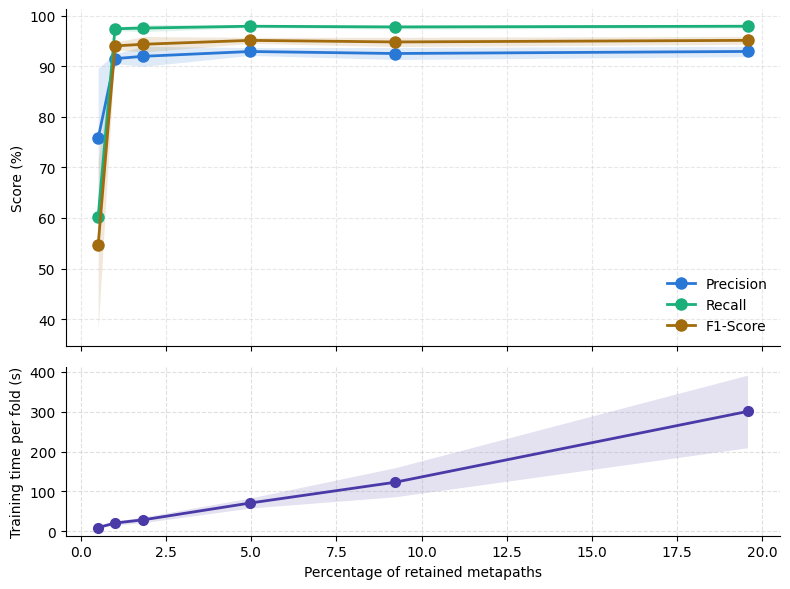

In [ ]:
import matplotlib.pyplot as plt

# Palette (dataviz skill's validated categorical slots):
#   slot 1 (blue) / slot 2 (aqua) for the two performance lines,
#   slot 5 (violet) for the single-series bar panel — kept out of the
#   line panel's hue range so it doesn't read as a third "performance" series.
COLOR_PRECISION = "#2a78d6"
COLOR_RECALL = "#1baf7a"
COLOR_F1 = "#a16b0e"
COLOR_TIME = "#4a3aa7"

plot_df = comparison_df.sort_values("pct_metapaths")
x = plot_df["pct_metapaths"].to_numpy()

fig, (ax_perf, ax_time) = plt.subplots(
    2, 1, figsize=(8, 6), sharex=True, height_ratios=[2, 1]
)

# --- Top panel: accuracy & PR-AUC, mean line + std band ---
for col, color, label in [
    ("precision_macro", COLOR_PRECISION, "Precision"),
    ("recall_macro", COLOR_RECALL, "Recall"),
    ("f1_macro", COLOR_F1, "F1-Score"),
]:
    mean = plot_df[f"{col}_mean"].to_numpy() * 100
    std = plot_df[f"{col}_std"].to_numpy() * 100
    ax_perf.plot(x * 100, mean, color=color, linewidth=2, marker="o", markersize=8, label=label)
    ax_perf.fill_between(x * 100, mean - std, mean + std, color=color, alpha=0.15, linewidth=0)

ax_perf.set_ylabel("Score (%)")
ax_perf.legend(frameon=False)
ax_perf.grid(axis="x", linestyle="--", alpha=0.3)
ax_perf.grid(axis="y", linestyle="--", alpha=0.3)
ax_perf.spines[["top", "right"]].set_visible(False)

# --- Bottom panel: fold training time, bars + std error bars ---
# bar width as a fraction of x so bars read consistently on a log x-axis
widths = x * 0.15
ax_time.plot(
    x * 100, plot_df["fold_time_mean"],
    color=COLOR_TIME, marker="o", linewidth=2, markersize=7,
)
ax_time.fill_between(x * 100, plot_df["fold_time_mean"] - plot_df["fold_time_std"], plot_df["fold_time_mean"] + plot_df["fold_time_std"], color=COLOR_TIME, alpha=0.15, linewidth=0)
ax_time.set_ylabel("Training time per fold (s)")
ax_time.set_xlabel("Percentage of retained metapaths")
#ax_time.set_xscale("log")
from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter

#ax_time.xaxis.set_major_locator(FixedLocator(x * 100))
#ax_time.xaxis.set_major_formatter(FuncFormatter(lambda v, p: f'{v:.1f}'))

ax_time.grid(True, axis="both", linestyle="--", alpha=0.4)
ax_time.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()


# CCTX Dataset

In [33]:
df2 = load_data("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/cctx-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/dme_report.csv")
df2["abs_difference"] = df2["difference"].abs()

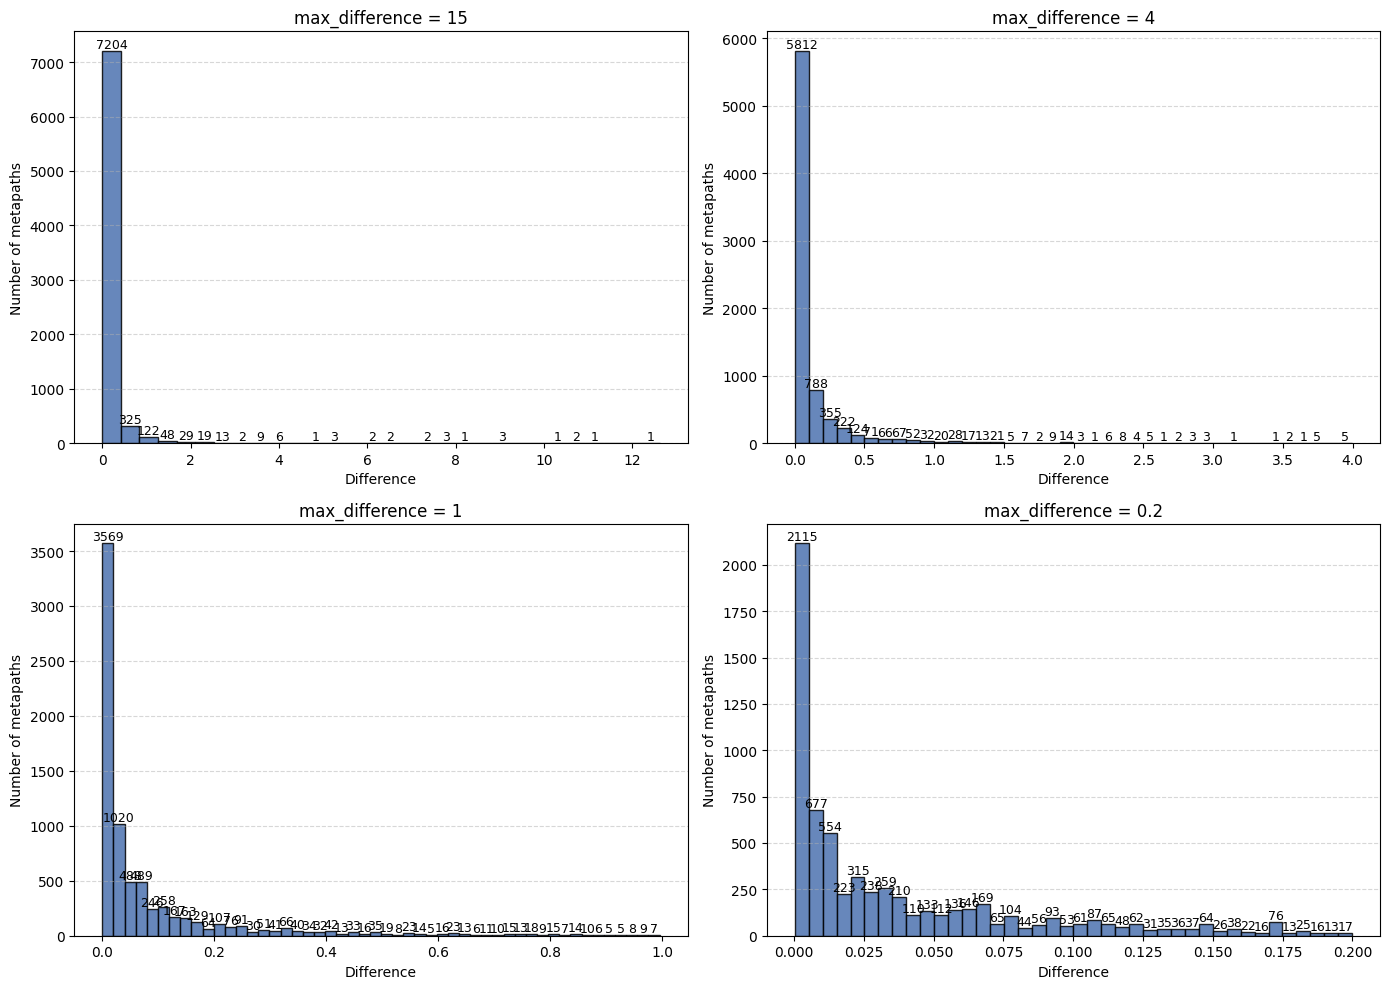

In [34]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
plot_histogram(df2, 50, 15, ax=ax, ax_index=0, interval_size=0.5)
plot_histogram(df2, 50, 4, ax=ax, ax_index=1, interval_size=0.1)
plot_histogram(df2, 50, 1, ax=ax, ax_index=2, interval_size=0.02)
plot_histogram(df2, 50, 0.2, ax=ax, ax_index=3, interval_size=0.005)
plt.tight_layout()

<module 'matplotlib.pyplot' from '/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/.venv/lib/python3.14/site-packages/matplotlib/pyplot.py'>

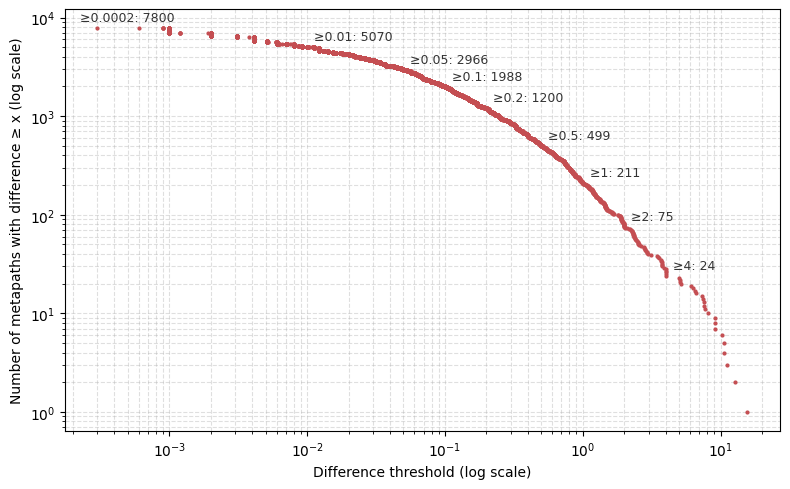

In [35]:
thresholds = [0.0002, 0.01, 0.05, 0.1, 0.2, 0.5, 1, 2, 4]
plt = plot_ccdf({
    "Cross-chain": df2,
}, thresholds)
plt

<module 'matplotlib.pyplot' from '/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/.venv/lib/python3.14/site-packages/matplotlib/pyplot.py'>

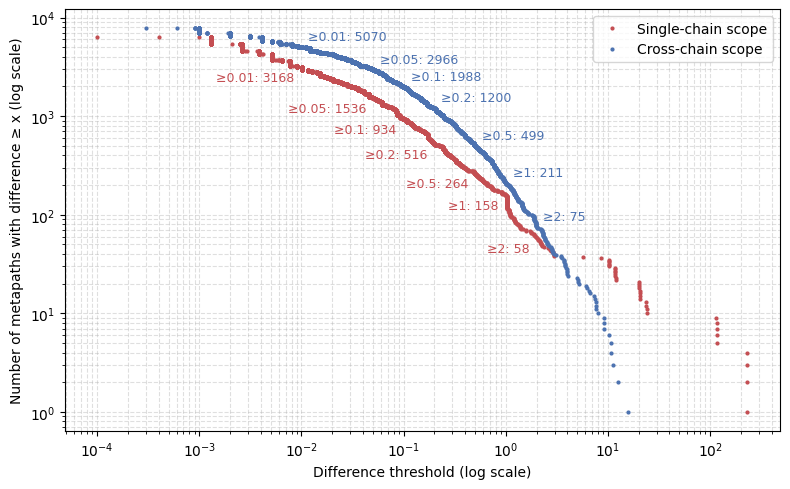

In [36]:
thresholds = [0.01, 0.05, 0.1, 0.2, 0.5, 1, 2]
plt = plot_ccdf({
    "Single-chain scope": df,
    "Cross-chain scope": df2,
}, thresholds)
plt

In [37]:
def min_threshold_for_percentage(df: pd.DataFrame, percentage: float, column: str = "difference") -> float:
    """
    Find the minimum 'difference' threshold t such that at least
    `percentage`% of the metapaths in df have difference >= t.
 
    In other words: what's the lowest bar I can set such that
    `percentage`% of the data still clears it?
 
    Parameters
    ----------
    df : pd.DataFrame
        Must contain the given `column` (default 'difference').
    percentage : float
        Target percentage of metapaths to retain, in (0, 100].
        e.g. 90 -> threshold below which 90% of metapaths remain (difference >= t).
    column : str
        Name of the numeric column to threshold on.
 
    Returns
    -------
    float
        The threshold value t.
    """
    if not (0 < percentage <= 100):
        raise ValueError("percentage must be in the range (0, 100]")
 
    values = df[column].dropna().to_numpy()
    if len(values) == 0:
        raise ValueError(f"No valid values found in column '{column}'")
 
    # We want: count(values >= t) / n >= percentage / 100
    # Equivalently: t is the (100 - percentage)-th percentile of the data,
    # using the "lower" interpolation so the guarantee (>= t) is not violated
    # by interpolated values that don't actually exist in the dataset.
    quantile_point = (100 - percentage) / 100
    threshold = np.quantile(values, quantile_point, method="lower")
 
    return float(threshold)
 
 
def thresholds_for_percentages(df: pd.DataFrame, percentages, column: str = "abs_difference") -> pd.DataFrame:
    """
    Convenience wrapper: compute thresholds for a list of percentages at once.
 
    Returns a DataFrame with columns: percentage, threshold, n_metapaths_retained
    """
    values = df[column].dropna().to_numpy()
    n_total = len(values)
 
    rows = []
    for p in percentages:
        t = min_threshold_for_percentage(df, p, column)
        n_retained = int((values >= t).sum())
        rows.append({
            "percentage": p,
            "threshold": t,
            "n_metapaths_retained": n_retained,
            "pct_actually_retained": round(100 * n_retained / n_total, 2),
        })
 
    return pd.DataFrame(rows)

thresholds_for_percentages(df2, [100, 50, 20, 10, 5, 2, 1, 0.5])

,percentage,threshold,n_metapaths_retained,pct_actually_retained
0,100.0,0.0003,7800,100.00
1,50.0,0.0254,3916,50.21
2,20.0,0.1404,1563,20.04
3,10.0,0.3266,790,10.13
4,5.0,0.6409,391,5.01
5,2.0,1.2350,157,2.01
6,1.0,1.9939,81,1.04
7,0.5,2.9705,40,0.51


## Evaluation Runs

In [57]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from types import SimpleNamespace

from cli import Cli
from dataset_generator.types import DATASET_TYPE

# Define the absolute path for the root directory for outputs here (and if possible, make sure to have a prepared _dataset folder)
OUTPUTS_ROOT = Path("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/cctx-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge")

The next cells will run the model training for different metapath difference thresholds.

This process can take a long time to finish.

**If you already have the models trained, you can skip this section and go to the evaluation section.**

In [45]:
dataset_path = OUTPUTS_ROOT.absolute() / "_dataset"
fixed_args = {
    "device": "cpu",  # Change to "cuda" if you have a GPU and want to use it
    "dataset": DATASET_TYPE.CCTX,
    "load_data": str(dataset_path),
    "new_dataset": None,
    "force_reload": False,
    "num_workers": 0,
    "tags": "mlpbased,tuningdme",

    "num_epochs": 100,
    "learning_rate": 0.005, # Notice that this is the same learning rate as the single-chain scope, unlike in the newer approach
    "augment_factor": 0,
    "rm_semantic_fusion": True,
    "early_stopping": 15,
    "kfolds": 5,
    "first_layer_channels": 128,
    "hidden_channels": 64,
    "dropout": 0.5,
    "input_drop": 0.0,
    "att_drop": 0.0,
    "n_fp_layers": 2,
    "n_mlp_layers": 2,
    "activation": "relu",
    "pooling": "mean",
    "residual": False,
    "random_seed": 42,
    "test_split": 0.15,
}

In [46]:
# Run for 0.5%
dme_val = min_threshold_for_percentage(df2, 0.5, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

Early stopping: 15
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 983 normal, 71 anomaly.
Identified 39 differential meta-paths for training.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 0.7504, val loss: 0.6983, PR-AUC (anomaly): 0.0563, f2-score (anomaly): 0.0000
              precision    recall  f1-score   support

           0       0.93      1.00      0.97       197
           1       0.00      0.00      0.00        14

    accuracy                           0.93       211
   macro avg       0.47      0.50      0.48       211
weighted avg       0.87      0.93      0.90       211

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch 2, train loss: 0.7020, val loss: 0.6607, PR-AUC (anomaly): 0.0962, f2-score (anomaly): 0.0000
              precision    recall  f1-score   support

           0       0.93      1.00      0.9

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/cctx-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme2.9705_nosf_es15_mlpbased_tuningdme__202608101955'

In [47]:
# Run for 1%
dme_val = min_threshold_for_percentage(df2, 1, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

Early stopping: 15
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 983 normal, 71 anomaly.
Identified 75 differential meta-paths for training.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 0.7532, val loss: 0.6890, PR-AUC (anomaly): 0.2232, f2-score (anomaly): 0.2917
              precision    recall  f1-score   support

           0       1.00      0.14      0.24       197
           1       0.08      1.00      0.14        14

    accuracy                           0.19       211
   macro avg       0.54      0.57      0.19       211
weighted avg       0.94      0.19      0.23       211

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch 2, train loss: 0.7162, val loss: 0.7085, PR-AUC (anomaly): 0.2356, f2-score (anomaly): 0.2756
              precision    recall  f1-score   support

           0       1.00      0.07      0.1

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/cctx-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme1.9939_nosf_es15_mlpbased_tuningdme__202608101958'

In [48]:
# Run for 2%
dme_val = min_threshold_for_percentage(df2, 2, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

Early stopping: 15
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 983 normal, 71 anomaly.
Identified 156 differential meta-paths for training.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 0.8007, val loss: 0.6722, PR-AUC (anomaly): 0.6141, f2-score (anomaly): 0.4276
              precision    recall  f1-score   support

           0       0.99      0.58      0.73       197
           1       0.14      0.93      0.24        14

    accuracy                           0.60       211
   macro avg       0.56      0.75      0.48       211
weighted avg       0.93      0.60      0.70       211

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch 2, train loss: 0.6550, val loss: 0.5335, PR-AUC (anomaly): 0.6181, f2-score (anomaly): 0.6024
              precision    recall  f1-score   support

           0       0.98      0.91      0.

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/cctx-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme1.235_nosf_es15_mlpbased_tuningdme__202608102002'

In [49]:
# Run for 5%
dme_val = min_threshold_for_percentage(df2, 5, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

Early stopping: 15
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 983 normal, 71 anomaly.
Identified 381 differential meta-paths for training.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 0.7340, val loss: 0.6636, PR-AUC (anomaly): 0.3492, f2-score (anomaly): 0.0000
              precision    recall  f1-score   support

           0       0.93      1.00      0.97       197
           1       0.00      0.00      0.00        14

    accuracy                           0.93       211
   macro avg       0.47      0.50      0.48       211
weighted avg       0.87      0.93      0.90       211

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch 2, train loss: 0.5173, val loss: 0.3177, PR-AUC (anomaly): 0.7830, f2-score (anomaly): 0.6757
              precision    recall  f1-score   support

           0       0.98      0.96      0.

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/cctx-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme0.6409_nosf_es15_mlpbased_tuningdme__202608102008'

In [50]:
# Run for 10%
dme_val = min_threshold_for_percentage(df2, 10, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

Early stopping: 15
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 983 normal, 71 anomaly.
Identified 769 differential meta-paths for training.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 0.6074, val loss: 0.4277, PR-AUC (anomaly): 0.2939, f2-score (anomaly): 0.5263
              precision    recall  f1-score   support

           0       0.98      0.85      0.91       197
           1       0.26      0.71      0.38        14

    accuracy                           0.84       211
   macro avg       0.62      0.78      0.64       211
weighted avg       0.93      0.84      0.88       211

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch 2, train loss: 0.4395, val loss: 0.3423, PR-AUC (anomaly): 0.6809, f2-score (anomaly): 0.6436
              precision    recall  f1-score   support

           0       0.99      0.84      0.

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/cctx-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme0.3266_nosf_es15_mlpbased_tuningdme__202608102022'

In [51]:
# Run for 20%
dme_val = min_threshold_for_percentage(df2, 20, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

Early stopping: 15
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 983 normal, 71 anomaly.
Identified 1549 differential meta-paths for training.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 0.6684, val loss: 0.5046, PR-AUC (anomaly): 0.6932, f2-score (anomaly): 0.5702
              precision    recall  f1-score   support

           0       0.99      0.77      0.87       197
           1       0.22      0.93      0.36        14

    accuracy                           0.78       211
   macro avg       0.61      0.85      0.61       211
weighted avg       0.94      0.78      0.83       211

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch 2, train loss: 0.4585, val loss: 0.1972, PR-AUC (anomaly): 0.8333, f2-score (anomaly): 0.7647
              precision    recall  f1-score   support

           0       0.99      0.92      0

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/cctx-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme0.1404_nosf_es15_mlpbased_tuningdme__202608102045'

## Results processing

**NOTE:** Make sure to run the OUTPUTS_ROOT cell first (available in the section above) to set the correct path to the outputs directory.

In [58]:
# Obtain all relevant run directories that match the pattern and contain a params.yaml file
run_dirs = sorted(
    p for p in OUTPUTS_ROOT.glob("train_epochs100_augment0_lr0.005_dme*")
    if p.is_dir() and (p / "params.yaml").exists()
)

print(f"Found {len(run_dirs)} run directories")
for p in run_dirs:
    print(p)

Found 6 run directories
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/cctx-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme0.1404_nosf_es15_mlpbased_tuningdme__202608102045
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/cctx-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme0.3266_nosf_es15_mlpbased_tuningdme__202608102022
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/cctx-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme0.6409_nosf_es15_mlpbased_tuningdme__202608102008
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/cctx-mlpbased-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme1.235_nosf_es15_mlpbased_t

In [59]:
import yaml

def load_run_config(run_dir: Path) -> dict:
    TOTAL_METAPATHS = 6475  # Total number of metapaths in the dataset
    with open(run_dir / "params.yaml") as f:
        doc = yaml.safe_load(f)

    return {
        "run_dir": run_dir,
        "run_name": run_dir.name,
        "dme_threshold": doc["dme"]["dme_threshold"],
        "reported_metapaths": doc["dme"]["reported_metapaths"],
        "pct_metapaths": doc["dme"]["reported_metapaths"] / TOTAL_METAPATHS,
        "total_samples": doc["dataset"]["stats"]["total_samples"],
        "anomaly_ratio": doc["dataset"]["stats"]["anomaly_ratio"],
    }

configs = [load_run_config(p) for p in run_dirs]
configs_df = pd.DataFrame(configs)
configs_df

,run_dir,run_name,dme_threshold,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.1404_nos...,0.1404,1549,0.239228,1241,0.0677
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.3266_nos...,0.3266,769,0.118764,1241,0.0677
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.6409_nos...,0.6409,381,0.058842,1241,0.0677
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme1.235_nosf...,1.2350,156,0.024093,1241,0.0677
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme1.9939_nos...,1.9939,75,0.011583,1241,0.0677
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme2.9705_nos...,2.9705,39,0.006023,1241,0.0677


In [60]:
def load_test_metrics(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "test_metrics.csv")
    metric_cols = [c for c in df.columns if c != "fold"]

    result = {"run_dir": run_dir}
    for col in metric_cols:
        result[f"{col}_mean"] = df[col].mean()
        result[f"{col}_std"] = df[col].std(ddof=0)

    result["precision_macro_mean"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).mean()
    result["precision_macro_std"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).std(ddof=0)
    result["recall_macro_mean"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).mean()
    result["recall_macro_std"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).std(ddof=0)
    result["f1_macro_mean"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).mean()
    result["f1_macro_std"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).std(ddof=0)
    return result

metrics = [load_test_metrics(p) for p in run_dirs]
metrics_df = pd.DataFrame(metrics)
metrics_df

,run_dir,test_loss_mean,test_loss_std,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,recall_normal_std,f1_normal_mean,...,pr_auc_mean,pr_auc_std,mcc_mean,mcc_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.110352,0.040981,0.985027,0.004002,0.993130,0.004273,0.990805,0.006897,0.991937,...,0.949533,0.022650,0.888693,0.023557,0.940984,0.029440,0.949248,0.026099,0.943251,0.012935
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.098830,0.077032,0.980749,0.013780,0.997688,0.004624,0.981609,0.014264,0.989524,...,0.880144,0.074810,0.876316,0.076536,0.905511,0.053956,0.975420,0.031304,0.934725,0.041908
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.069331,0.014275,0.982888,0.004002,0.994213,0.000025,0.987356,0.004301,0.990768,...,0.919135,0.045493,0.875119,0.025698,0.920843,0.022827,0.955217,0.002150,0.936898,0.013361
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.193423,0.040507,0.965775,0.009918,0.989520,0.002228,0.973563,0.012902,0.981418,...,0.852201,0.064558,0.769114,0.036234,0.855712,0.038343,0.917551,0.009153,0.881403,0.022741
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.168042,0.022782,0.967914,0.008284,0.989514,0.002321,0.975862,0.008447,0.982622,...,0.791368,0.065785,0.777255,0.043914,0.861344,0.032396,0.918700,0.016228,0.886572,0.023614
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.689466,0.013543,0.349733,0.138485,0.956190,0.018690,0.318391,0.163994,0.453665,...,0.127848,0.007322,0.053506,0.041596,0.516530,0.012324,0.543811,0.035429,0.296320,0.082839


In [61]:
def load_fold_durations(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "fold_durations.csv")
    return {
        "run_dir": run_dir,
        "fold_time_mean": df["time"].mean(),
        "fold_time_std": df["time"].std(ddof=0),  # match summary.txt convention
        "fold_time_total": df["time"].sum(),
    }

durations = [load_fold_durations(p) for p in run_dirs]
durations_df = pd.DataFrame(durations)
durations_df


,run_dir,fold_time_mean,fold_time_std,fold_time_total
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,526.774,195.934929,2633.87
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,257.108,56.931350,1285.54
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,154.632,22.166517,773.16
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,60.254,16.921492,301.27
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,39.746,13.990532,198.73
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,26.746,9.597522,133.73


In [62]:
comparison_df = (
    configs_df
    .merge(metrics_df, on="run_dir")
    .merge(durations_df, on="run_dir")
    .sort_values(["dme_threshold"])
    .reset_index(drop=True)
)
comparison_df

,run_dir,run_name,dme_threshold,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio,test_loss_mean,test_loss_std,accuracy_mean,...,mcc_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,fold_time_mean,fold_time_std,fold_time_total
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.1404_nos...,0.1404,1549,0.239228,1241,0.0677,0.110352,0.040981,0.985027,...,0.023557,0.940984,0.029440,0.949248,0.026099,0.943251,0.012935,526.774,195.934929,2633.87
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.3266_nos...,0.3266,769,0.118764,1241,0.0677,0.098830,0.077032,0.980749,...,0.076536,0.905511,0.053956,0.975420,0.031304,0.934725,0.041908,257.108,56.931350,1285.54
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.6409_nos...,0.6409,381,0.058842,1241,0.0677,0.069331,0.014275,0.982888,...,0.025698,0.920843,0.022827,0.955217,0.002150,0.936898,0.013361,154.632,22.166517,773.16
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme1.235_nosf...,1.2350,156,0.024093,1241,0.0677,0.193423,0.040507,0.965775,...,0.036234,0.855712,0.038343,0.917551,0.009153,0.881403,0.022741,60.254,16.921492,301.27
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme1.9939_nos...,1.9939,75,0.011583,1241,0.0677,0.168042,0.022782,0.967914,...,0.043914,0.861344,0.032396,0.918700,0.016228,0.886572,0.023614,39.746,13.990532,198.73
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme2.9705_nos...,2.9705,39,0.006023,1241,0.0677,0.689466,0.013543,0.349733,...,0.041596,0.516530,0.012324,0.543811,0.035429,0.296320,0.082839,26.746,9.597522,133.73


In [63]:
trimmed_df = comparison_df[[
    "pct_metapaths", 
    "reported_metapaths",
    "dme_threshold",
    "accuracy_mean",
    "accuracy_std",
    "precision_normal_mean",
    "precision_normal_std",
    "recall_normal_mean",
    "recall_normal_std",
    "f1_normal_mean",
    "f1_normal_std",
    "precision_anomaly_mean",
    "precision_anomaly_std",
    "recall_anomaly_mean",
    "recall_anomaly_std",
    "f1_anomaly_mean",
    "f1_anomaly_std",
    "f2_anomaly_mean",
    "f2_anomaly_std",
    "pr_auc_mean",
    "pr_auc_std",
    "fold_time_mean",
    "fold_time_std",
]]
trimmed_df

,pct_metapaths,reported_metapaths,dme_threshold,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,recall_normal_std,f1_normal_mean,...,recall_anomaly_mean,recall_anomaly_std,f1_anomaly_mean,f1_anomaly_std,f2_anomaly_mean,f2_anomaly_std,pr_auc_mean,pr_auc_std,fold_time_mean,fold_time_std
0,0.239228,1549,0.1404,0.985027,0.004002,0.993130,0.004273,0.990805,0.006897,0.991937,...,0.907692,5.756396e-02,0.894564,0.023784,0.901387,0.034993,0.949533,0.022650,526.774,195.934929
1,0.118764,769,0.3266,0.980749,0.013780,0.997688,0.004624,0.981609,0.014264,0.989524,...,0.969231,6.153846e-02,0.879925,0.076345,0.929778,0.058556,0.880144,0.074810,257.108,56.931350
2,0.058842,381,0.6409,0.982888,0.004002,0.994213,0.000025,0.987356,0.004301,0.990768,...,0.923077,1.110223e-16,0.883028,0.024547,0.906461,0.010288,0.919135,0.045493,154.632,22.166517
3,0.024093,156,1.2350,0.965775,0.009918,0.989520,0.002228,0.973563,0.012902,0.981418,...,0.861538,3.076923e-02,0.781388,0.039933,0.826075,0.005938,0.852201,0.064558,60.254,16.921492
4,0.011583,75,1.9939,0.967914,0.008284,0.989514,0.002321,0.975862,0.008447,0.982622,...,0.861538,3.076923e-02,0.790522,0.042692,0.831126,0.030987,0.791368,0.065785,39.746,13.990532
5,0.006023,39,2.9705,0.349733,0.138485,0.956190,0.018690,0.318391,0.163994,0.453665,...,0.769231,2.120623e-01,0.138975,0.014538,0.271024,0.040055,0.127848,0.007322,26.746,9.597522


In [64]:
PCT_SCALE_EXCLUDE = {"fold_time"}  # keep seconds as seconds, not *100

def format_stat(mean, std, base):
    scale = 1 if base in PCT_SCALE_EXCLUDE else 100
    return f"{mean * scale:.2f} \u00b1 {std * scale:05.2f}"

metric_bases = [c[:-5] for c in trimmed_df.columns if c.endswith("_mean")]

display_df = pd.DataFrame(index=trimmed_df.index)
display_df["reported_metapaths"] = trimmed_df["reported_metapaths"].map(lambda v: f"{v:.0f}")
display_df["dme_threshold"] = trimmed_df["dme_threshold"].map(lambda v: f"{v:.4f}")
for base in metric_bases:
    display_df[base] = trimmed_df.apply(
        lambda row: format_stat(row[f"{base}_mean"], row[f"{base}_std"], base), axis=1
    )

display_df.insert(0, "pct_metapaths", (trimmed_df["pct_metapaths"]*100).map(lambda v: f"{v:.2f}%"))
display_df = display_df.set_index("pct_metapaths")

final_table = display_df.T
final_table


pct_metapaths,23.92%,11.88%,5.88%,2.41%,1.16%,0.60%
reported_metapaths,1549,769,381,156,75,39
dme_threshold,0.1404,0.3266,0.6409,1.2350,1.9939,2.9705
accuracy,98.50 ± 00.40,98.07 ± 01.38,98.29 ± 00.40,96.58 ± 00.99,96.79 ± 00.83,34.97 ± 13.85
precision_normal,99.31 ± 00.43,99.77 ± 00.46,99.42 ± 00.00,98.95 ± 00.22,98.95 ± 00.23,95.62 ± 01.87
recall_normal,99.08 ± 00.69,98.16 ± 01.43,98.74 ± 00.43,97.36 ± 01.29,97.59 ± 00.84,31.84 ± 16.40
f1_normal,99.19 ± 00.22,98.95 ± 00.76,99.08 ± 00.22,98.14 ± 00.56,98.26 ± 00.46,45.37 ± 17.40
precision_anomaly,88.88 ± 06.21,81.33 ± 10.72,84.75 ± 04.56,72.19 ± 07.88,73.32 ± 06.43,7.69 ± 00.65
recall_anomaly,90.77 ± 05.76,96.92 ± 06.15,92.31 ± 00.00,86.15 ± 03.08,86.15 ± 03.08,76.92 ± 21.21
f1_anomaly,89.46 ± 02.38,87.99 ± 07.63,88.30 ± 02.45,78.14 ± 03.99,79.05 ± 04.27,13.90 ± 01.45
f2_anomaly,90.14 ± 03.50,92.98 ± 05.86,90.65 ± 01.03,82.61 ± 00.59,83.11 ± 03.10,27.10 ± 04.01


In [65]:
# Turn the unicode ± into LaTeX math syntax, and escape underscores in row labels
import re

METRIC_LABELS = {
    "reported_metapaths": "Reported Metapaths",
    "dme_threshold": "DME Threshold",
    "test_loss": "Test Loss (\\%)",
    "accuracy": "Accuracy (\\%)",
    "precision_normal": "Precision (Normal) (\\%)",
    "recall_normal": "Recall (Normal) (\\%)",
    "f1_normal": "F1 (Normal) (\\%)",
    "precision_anomaly": "Precision (Anomaly) (\\%)",
    "recall_anomaly": "Recall (Anomaly) (\\%)",
    "f1_anomaly": "F1 (Anomaly) (\\%)",
    "f2_anomaly": "F2 (Anomaly) (\\%)",
    "pr_auc": "PR-AUC (\\%)",
    "fold_time": "Fold Training Time (sec/fold)",
}

def to_math_pm(s: str) -> str:
    return re.sub(r"(-?[\d.]+) \u00b1 (-?[\d.]+)", r"$\1 \\pm \2$", s)

latex_ready = final_table.map(to_math_pm)
latex_ready = latex_ready.rename(index=METRIC_LABELS)
latex_ready.index = latex_ready.index.str.replace("_", r"\_", regex=False)

latex_str = latex_ready.to_latex(
    escape=False,  # cell values already contain LaTeX ($\pm$), don't double-escape
    column_format="l" + "c" * len(latex_ready.columns),
    caption="Effect of the DME threshold on test-set performance",
    label="tab:dme_threshold_comparison",
)
print(latex_str)

with open("dme_threshold_comparison.tex", "w") as f:
    f.write(latex_str)


\begin{table}
\caption{Effect of the DME threshold on test-set performance}
\label{tab:dme_threshold_comparison}
\begin{tabular}{lcccccc}
\toprule
pct_metapaths & 23.92% & 11.88% & 5.88% & 2.41% & 1.16% & 0.60% \\
\midrule
Reported Metapaths & 1549 & 769 & 381 & 156 & 75 & 39 \\
DME Threshold & 0.1404 & 0.3266 & 0.6409 & 1.2350 & 1.9939 & 2.9705 \\
Accuracy (\%) & $98.50 \pm 00.40$ & $98.07 \pm 01.38$ & $98.29 \pm 00.40$ & $96.58 \pm 00.99$ & $96.79 \pm 00.83$ & $34.97 \pm 13.85$ \\
Precision (Normal) (\%) & $99.31 \pm 00.43$ & $99.77 \pm 00.46$ & $99.42 \pm 00.00$ & $98.95 \pm 00.22$ & $98.95 \pm 00.23$ & $95.62 \pm 01.87$ \\
Recall (Normal) (\%) & $99.08 \pm 00.69$ & $98.16 \pm 01.43$ & $98.74 \pm 00.43$ & $97.36 \pm 01.29$ & $97.59 \pm 00.84$ & $31.84 \pm 16.40$ \\
F1 (Normal) (\%) & $99.19 \pm 00.22$ & $98.95 \pm 00.76$ & $99.08 \pm 00.22$ & $98.14 \pm 00.56$ & $98.26 \pm 00.46$ & $45.37 \pm 17.40$ \\
Precision (Anomaly) (\%) & $88.88 \pm 06.21$ & $81.33 \pm 10.72$ & $84.75 \pm 04.

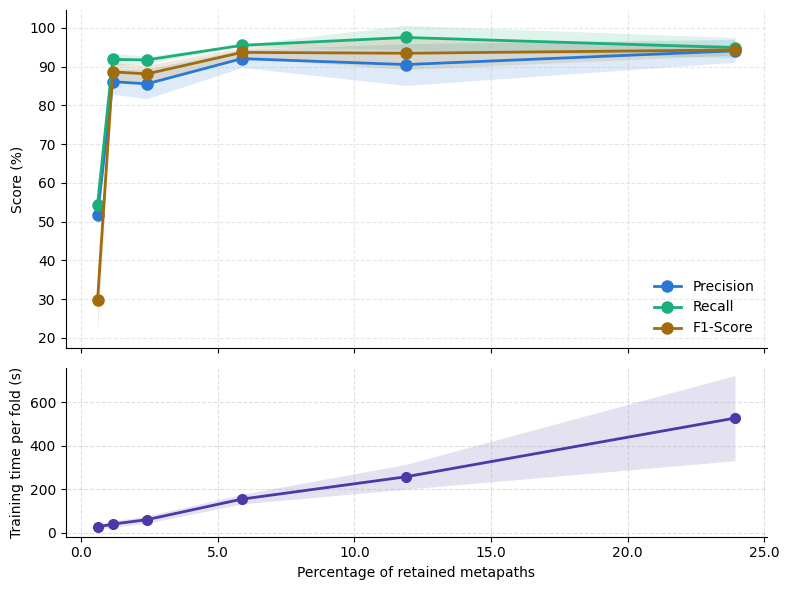

In [ ]:
import matplotlib.pyplot as plt

# Palette (dataviz skill's validated categorical slots):
#   slot 1 (blue) / slot 2 (aqua) for the two performance lines,
#   slot 5 (violet) for the single-series bar panel — kept out of the
#   line panel's hue range so it doesn't read as a third "performance" series.
COLOR_PRECISION = "#2a78d6"
COLOR_RECALL = "#1baf7a"
COLOR_F1 = "#a16b0e"
COLOR_TIME = "#4a3aa7"

plot_df = comparison_df.sort_values("pct_metapaths")
x = plot_df["pct_metapaths"].to_numpy()

fig, (ax_perf, ax_time) = plt.subplots(
    2, 1, figsize=(8, 6), sharex=True, height_ratios=[2, 1]
)

# --- Top panel: accuracy & PR-AUC, mean line + std band ---
for col, color, label in [
    ("precision_macro", COLOR_PRECISION, "Precision"),
    ("recall_macro", COLOR_RECALL, "Recall"),
    ("f1_macro", COLOR_F1, "F1-Score"),
]:
    mean = plot_df[f"{col}_mean"].to_numpy() * 100
    std = plot_df[f"{col}_std"].to_numpy() * 100
    ax_perf.plot(x * 100, mean, color=color, linewidth=2, marker="o", markersize=8, label=label)
    ax_perf.fill_between(x * 100, mean - std, mean + std, color=color, alpha=0.15, linewidth=0)

ax_perf.set_ylabel("Score (%)")
ax_perf.legend(frameon=False)
ax_perf.grid(axis="x", linestyle="--", alpha=0.3)
ax_perf.grid(axis="y", linestyle="--", alpha=0.3)
ax_perf.spines[["top", "right"]].set_visible(False)

# --- Bottom panel: fold training time, bars + std error bars ---
# bar width as a fraction of x so bars read consistently on a log x-axis
widths = x * 0.15
ax_time.plot(
    x * 100, plot_df["fold_time_mean"],
    color=COLOR_TIME, marker="o", linewidth=2, markersize=7,
)
ax_time.fill_between(x * 100, plot_df["fold_time_mean"] - plot_df["fold_time_std"], plot_df["fold_time_mean"] + plot_df["fold_time_std"], color=COLOR_TIME, alpha=0.15, linewidth=0)
ax_time.set_ylabel("Training time per fold (s)")
ax_time.set_xlabel("Percentage of retained metapaths")
#ax_time.set_xscale("log")
from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter

#ax_time.xaxis.set_major_locator(FixedLocator(x * 100))
ax_time.xaxis.set_major_formatter(FuncFormatter(lambda v, p: f'{v:.1f}'))

ax_time.grid(True, axis="both", linestyle="--", alpha=0.4)
ax_time.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()
